In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [9]:
df = pd.read_csv("../data/laptop_processed.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1275, 28)


,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,...,Hybrid_GB,Total_Storage_GB,Storage_Type,Resolution_Width,Resolution_Height,Touchscreen,IPS,CPU_Family,GPU_Family,OS_Family
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,...,0.0,128.0,SSD,2560,1600,0,1,Core i5,Other,macOS
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,...,0.0,128.0,Flash,1440,900,0,0,Core i5,Intel HD,macOS
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,...,0.0,256.0,SSD,1920,1080,0,0,Core i5,Intel HD,No OS
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,...,0.0,512.0,SSD,2880,1800,0,1,Core i7,AMD Radeon,macOS
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,...,0.0,256.0,SSD,2560,1600,0,1,Core i5,Other,macOS


In [10]:
X = df.drop("Price (Euro)", axis=1)
y = df["Price (Euro)"]

In [11]:
print(X.shape)
print(y.shape)

(1275, 27)
(1275,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (1020, 27)
Testing data: (255, 27)
Training target: (1020,)
Testing target: (255,)


In [13]:
model = joblib.load("../models/laptop_price_model.pkl")
preprocessor = joblib.load("../models/preprocessor.pkl")

print("Model loaded:", type(model))
print("Preprocessor loaded:", type(preprocessor))

Model loaded: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Preprocessor loaded: <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [14]:
print("Number of model features:", len(model.feature_importances_))
print("Number of preprocessed features:", len(
    preprocessor.get_feature_names_out()
))

Number of model features: 80
Number of preprocessed features: 80


In [15]:
X_test_processed = preprocessor.transform(X_test)

print("Original test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

Original test shape: (255, 27)
Processed test shape: (255, 80)


In [16]:
y_pred = model.predict(X_test_processed)

print("Number of predictions:", len(y_pred))
print("First 10 predictions:")
print(y_pred[:10])

Number of predictions: 255
First 10 predictions:
[ 668.9224988   774.58907183 1611.78984383  840.90576889 1576.16697734
  619.362986    965.01864444  325.31979727 1835.31441794  739.55450603]


In [17]:
comparison = pd.DataFrame({
    "Actual Price (€)": y_test.values,
    "Predicted Price (€)": y_pred
})

comparison["Error (€)"] = (
    comparison["Actual Price (€)"]
    - comparison["Predicted Price (€)"]
)

comparison.head(10)

,Actual Price (€),Predicted Price (€),Error (€)
0,650.00,668.922499,-18.922499
1,716.00,774.589072,-58.589072
2,1584.00,1611.789844,-27.789844
3,1020.00,840.905769,179.094231
4,1749.00,1576.166977,172.833023
5,557.37,619.362986,-61.992986
6,999.00,965.018644,33.981356
7,330.00,325.319797,4.680203
8,2267.86,1835.314418,432.545582
9,682.00,739.554506,-57.554506


In [18]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("-------------------------")
print(f"MAE  : €{mae:.2f}")
print(f"RMSE : €{rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation Results
-------------------------
MAE  : €179.98
RMSE : €268.95
R²   : 0.8543


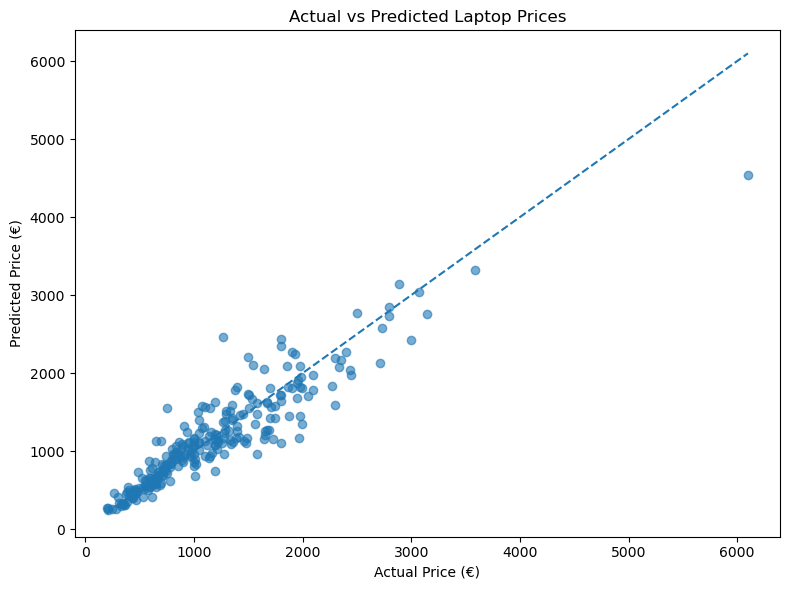

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Price (€)")
plt.ylabel("Predicted Price (€)")
plt.title("Actual vs Predicted Laptop Prices")

# Perfect prediction line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [20]:
residuals = y_test - y_pred

print("Mean Residual:", residuals.mean())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())

Mean Residual: 8.475425028961576
Minimum Residual: -1197.7403777777777
Maximum Residual: 1562.7159999999994


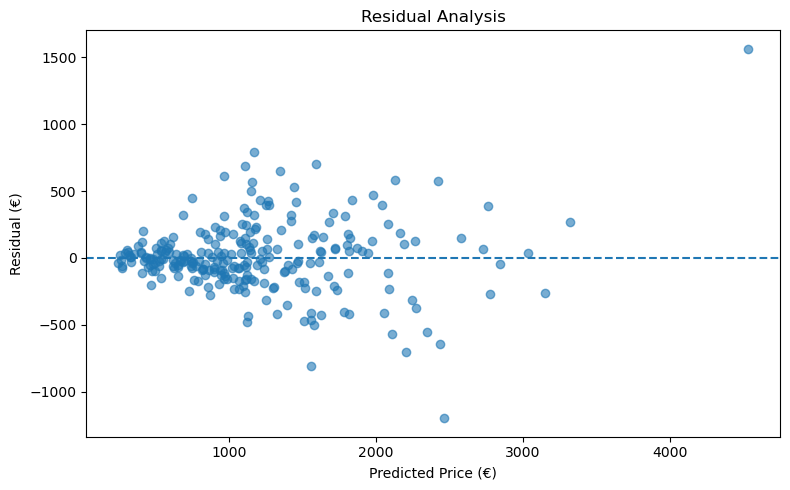

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price (€)")
plt.ylabel("Residual (€)")
plt.title("Residual Analysis")

plt.tight_layout()
plt.show()